# E-Commerce Public Dataset — End-to-End Analysis

**Project goal:** Build a complete data analysis pipeline on the Olist Brazilian
E-Commerce Public Dataset, following the **SMART** methodology, to answer two
business questions and feed an interactive Streamlit dashboard.

## Business Questions

1. **Product Performance**: Which top 10 product categories generated the highest total revenue during the full calendar year of 2018?
2. **Customer Segmentation (Advanced)**: What does the customer base look like when segmented with **RFM (Recency, Frequency, Monetary)** analysis, using the last available 12 months of transactional data?

## SMART Framing

| | |
|---|---|
| **Specific** | Revenue by product category (2018) and customer segments via RFM, both scoped to named columns and a fixed time window. |
| **Measurable** | Revenue in R$, order/customer counts, and quantile-based RFM scores (1–4) — all numeric and reproducible. |
| **Achievable** | Computable directly from the six provided tables with standard `pandas` joins and aggregations. |
| **Relevant** | Directly informs which categories to invest marketing budget in, and which customers need retention vs. win-back campaigns. |
| **Time-bound** | Question 1 is scoped to calendar year 2018; the RFM analysis uses a rolling 12-month window ending at the most recent order in the data. |

## Notebook Structure

- **Phase 1: Data Wrangling:** gather, assess, and clean all six source tables; export a single consolidated file (`dashboard/main_data.csv`) for the dashboard.
- **Phase 2: Exploratory Data Analysis & RFM:** answer both business questions.
- **Phase 3: Data Visualization:** two polished, explanatory charts.
- **Conclusion:** key findings and recommendations.


In [3]:
%pip install pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


---
# Phase 1 — Data Wrangling

## 1.1 Gathering Data

In [4]:
customers_df = pd.read_csv('D:/Karir/Dicoding/Laporan Akhir/data/customers_dataset.csv')
orders_df = pd.read_csv('D:/Karir/Dicoding/Laporan Akhir/data/orders_dataset.csv')
order_items_df = pd.read_csv('D:/Karir/Dicoding/Laporan Akhir/data/order_items_dataset.csv')
order_payments_df = pd.read_csv('D:/Karir/Dicoding/Laporan Akhir/data/order_payments_dataset.csv')
products_df = pd.read_csv('D:/Karir/Dicoding/Laporan Akhir/data/products_dataset.csv')
category_translation_df = pd.read_csv('D:/Karir/Dicoding/Laporan Akhir/data/product_category_name_translation.csv')

for name, df in [
    ("customers_df", customers_df), ("orders_df", orders_df),
    ("order_items_df", order_items_df), ("order_payments_df", order_payments_df),
    ("products_df", products_df), ("category_translation_df", category_translation_df),
]:
    print(f"{name}: {df.shape}")

customers_df: (99441, 5)
orders_df: (99441, 8)
order_items_df: (112650, 7)
order_payments_df: (103886, 5)
products_df: (32951, 9)
category_translation_df: (71, 2)


## 1.2 Assessing Data

In [5]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [6]:
print("Missing values — orders_df:")
print(orders_df.isna().sum())

Missing values — orders_df:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [7]:
print("order_status distribution:")
print(orders_df['order_status'].value_counts())

order_status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [8]:
print("Duplicate rows check:")
for name, df in [
    ("customers_df", customers_df), ("orders_df", orders_df),
    ("order_items_df", order_items_df), ("order_payments_df", order_payments_df),
    ("products_df", products_df),
]:
    print(f"  {name}: {df.duplicated().sum()} duplicates")

print("\nMissing values — products_df:")
print(products_df.isna().sum())

Duplicate rows check:
  customers_df: 0 duplicates
  orders_df: 0 duplicates
  order_items_df: 0 duplicates
  order_payments_df: 0 duplicates
  products_df: 0 duplicates

Missing values — products_df:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


**Assessment summary:**
- `orders_df` has missing values in the delivery-related timestamp columns —
  expected, since not every order reaches every fulfillment stage (e.g.
  canceled or still-in-transit orders).
- `order_status` contains several non-`delivered` states (`shipped`,
  `canceled`, `processing`, `unavailable`, etc.). Revenue and RFM analysis
  should only count orders that actually completed, so we filter on
  `order_status == 'delivered'`.
- `products_df` has a small number of missing `product_category_name` values
  (untagged products) — handled in cleaning below.
- No duplicate rows were found in any table.

## 1.3 Cleaning Data

Four cleaning operations, applied in order:
1. Convert every timestamp column to a real `datetime64` dtype.
2. Keep only orders with `order_status == 'delivered'` **and** a valid
   `order_purchase_timestamp` (the only date field every analysis below
   depends on).
3. Map Portuguese product categories to English via the translation table,
   falling back to the original Portuguese name for any category missing a
   translation row (so products aren't silently dropped).
4. Merge everything into one consolidated, order-item-level table and save it
   as `dashboard/main_data.csv` for the Streamlit app.

In [9]:
# --- Convert timestamp columns to real datetime objects ---
order_datetime_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date',
]
for col in order_datetime_cols:
    orders_df[col] = pd.to_datetime(orders_df[col], errors='coerce')

order_items_df['shipping_limit_date'] = pd.to_datetime(
    order_items_df['shipping_limit_date'], errors='coerce'
)

print(orders_df[order_datetime_cols].dtypes)

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


In [10]:
# --- Keep only delivered orders with a valid purchase timestamp ---
orders_clean = orders_df[
    (orders_df['order_status'] == 'delivered')
    & (orders_df['order_purchase_timestamp'].notna())
].copy()

print(f"Orders before cleaning: {len(orders_df):,}")
print(f"Orders after keeping only delivered + valid timestamp: {len(orders_clean):,}")

Orders before cleaning: 99,441
Orders after keeping only delivered + valid timestamp: 96,478


In [11]:
# --- Map Portuguese product categories -> English ---
products_translated = products_df.merge(
    category_translation_df, on='product_category_name', how='left'
)
# A handful of categories have no matching translation row; fall back to the
# original Portuguese name rather than dropping the product.
products_translated['product_category_name_english'] = (
    products_translated['product_category_name_english']
    .fillna(products_translated['product_category_name'])
)

products_translated[['product_id', 'product_category_name',
                      'product_category_name_english']].head()

,product_id,product_category_name,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares


In [12]:
# --- Build one consolidated, order-item-level table ---
main_df = (
    order_items_df
    .merge(
        products_translated[['product_id', 'product_category_name_english']],
        on='product_id', how='left'
    )
    .merge(
        orders_clean[['order_id', 'customer_id', 'order_status',
                      'order_purchase_timestamp', 'order_delivered_customer_date',
                      'order_estimated_delivery_date']],
        on='order_id', how='inner'   # inner: drop items whose order didn't pass the filter above
    )
    .merge(
        customers_df[['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']],
        on='customer_id', how='left'
    )
)

# Attach total payment value per order — useful as a revenue cross-check / dashboard KPI
payments_per_order = order_payments_df.groupby('order_id', as_index=False)['payment_value'].sum()
main_df = main_df.merge(payments_per_order, on='order_id', how='left')

# A few products carry no category at all (untagged in the source data)
main_df['product_category_name_english'] = main_df['product_category_name_english'].fillna('unknown')

print(f"Final consolidated table shape: {main_df.shape}")
main_df.head(3)

Final consolidated table shape: (110197, 17)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,cool_stuff,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,campos dos goytacazes,RJ,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,pet_shop,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87,furniture_decor,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG,216.87


In [13]:
print("Null check on the consolidated table:")
print(main_df.isna().sum())

Null check on the consolidated table:
order_id                         0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
product_category_name_english    0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_delivered_customer_date    8
order_estimated_delivery_date    0
customer_unique_id               0
customer_city                    0
customer_state                   0
payment_value                    3
dtype: int64


In [14]:
# --- Persist the cleaned, consolidated dataset for the Streamlit dashboard ---
os.makedirs('dashboard', exist_ok=True)
main_df.to_csv('dashboard/main_data.csv', index=False)
print("Saved dashboard/main_data.csv —", main_df.shape)

Saved dashboard/main_data.csv — (110197, 17)


---
# Phase 2 — Exploratory Data Analysis & RFM

## 2.1 Business Question 1 — Top 10 Product Categories by 2018 Revenue

Filtering to the full calendar year 2018 and summing `price` per English
category name.

In [15]:
orders_2018 = main_df[main_df['order_purchase_timestamp'].dt.year == 2018]

category_revenue_2018 = (
    orders_2018.groupby('product_category_name_english')['price']
    .sum()
    .sort_values(ascending=False)
    .reset_index(name='total_revenue')
)

top10_categories_2018 = category_revenue_2018.head(10)
top10_categories_2018

,product_category_name_english,total_revenue
0,health_beauty,755724.50
1,watches_gifts,687855.20
2,bed_bath_table,532358.85
3,sports_leisure,517166.26
4,computers_accessories,496269.30
5,housewares,391823.46
6,furniture_decor,381649.57
7,auto,343288.30
8,baby,250615.79
9,cool_stuff,227743.70


## 2.2 Business Question 2 — RFM Analysis (Last 12 Months)

RFM is computed per `customer_unique_id`, using only orders placed within the
last 12 months of the most recent purchase date in the cleaned dataset:

- **Recency** — days between a customer's most recent purchase and the
  dataset's max date (lower = more recently active).
- **Frequency** — count of *distinct* `order_id`s placed by the customer.
- **Monetary** — sum of `price` across all their order items.

Each metric is converted into a 1–4 quartile score (4 = best), and the three
scores are combined into clear business segments using simple, explainable
rules rather than an opaque clustering algorithm — easier to act on for a
marketing team.

In [16]:
max_date = main_df['order_purchase_timestamp'].max()
window_start = max_date - pd.DateOffset(months=12)
rfm_window = main_df[main_df['order_purchase_timestamp'] >= window_start].copy()

print(f"Most recent purchase date in the dataset: {max_date.date()}")
print(f"RFM window start (last 12 months):         {window_start.date()}")
print(f"Order-item rows inside the window:          {len(rfm_window):,}")

Most recent purchase date in the dataset: 2018-08-29
RFM window start (last 12 months):         2017-08-29
Order-item rows inside the window:          85,383


In [17]:
rfm_df = (
    rfm_window.groupby('customer_unique_id')
    .agg(
        last_purchase_date=('order_purchase_timestamp', 'max'),
        frequency=('order_id', 'nunique'),
        monetary=('price', 'sum'),
    )
    .reset_index()
)
rfm_df['recency'] = (max_date - rfm_df['last_purchase_date']).dt.days
rfm_df = rfm_df[['customer_unique_id', 'recency', 'frequency', 'monetary']]

print(f"Unique customers in the RFM window: {len(rfm_df):,}")
rfm_df.describe()

Unique customers in the RFM window: 72,620


,recency,frequency,monetary
count,72620.000000,72620.000000,72620.000000
mean,172.569334,1.027334,141.228375
std,100.068044,0.186237,212.199960
min,0.000000,1.000000,0.850000
25%,88.000000,1.000000,47.900000
50%,172.000000,1.000000,89.800000
75%,260.000000,1.000000,152.000000
max,364.000000,11.000000,13440.000000


In [18]:
def score_quantile(series, ascending):
    '''Scores a metric into quartiles 1-4 (4 = best).

    ascending=True  -> lower raw values are BETTER  (used for recency)
    ascending=False -> higher raw values are BETTER (used for frequency, monetary)

    Uses rank() before qcut() so that ties don't break quantile cuts, and
    falls back to equal-width cut() if the data has too little variation
    for 4 clean quantile buckets (common on small samples).
    '''
    ranks = series.rank(method='first', ascending=ascending)
    try:
        scores = pd.qcut(ranks, 4, labels=[1, 2, 3, 4]).astype(int)
    except ValueError:
        scores = pd.cut(ranks, 4, labels=[1, 2, 3, 4]).astype(int)
    return scores

rfm_df['R_score'] = score_quantile(rfm_df['recency'], ascending=True)
rfm_df['F_score'] = score_quantile(rfm_df['frequency'], ascending=False)
rfm_df['M_score'] = score_quantile(rfm_df['monetary'], ascending=False)
rfm_df['RFM_score'] = (
    rfm_df['R_score'].astype(str) + rfm_df['F_score'].astype(str) + rfm_df['M_score'].astype(str)
)

rfm_df.head()

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,129.90,2,1,2,212
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,18.90,2,1,4,214
2,0000f6ccb0745a6a4b88665a16c9f078,320,1,25.99,4,1,4,414
3,0004aac84e0df4da2b147fca70cf8255,287,1,180.00,4,1,1,411
4,0004bd2a26a76fe21f786e4fbd80607f,145,1,154.00,2,1,1,211


In [19]:
def segment_customer(row):
    '''Manual business-rule segmentation on the R/F/M quartile scores.'''
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Best Customers'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New / Promising'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Hibernating'
    else:
        return 'Need Attention'

rfm_df['segment'] = rfm_df.apply(segment_customer, axis=1)

segment_distribution = rfm_df['segment'].value_counts()
segment_distribution

segment
At Risk            18013
Need Attention     17900
Loyal Customers    17169
Hibernating         9427
New / Promising     8983
Best Customers      1128
Name: count, dtype: int64

**Segment definitions:**

| Segment | Meaning |
|---|---|
| **Best Customers** | Recently active, frequent, high spend — top priority for loyalty rewards. |
| **Loyal Customers** | Consistently active and engaged, slightly below the top tier. |
| **New / Promising** | Very recent first-time-ish buyers — nurture into loyal customers. |
| **At Risk** | Used to order frequently but haven't purchased recently — win-back candidates. |
| **Hibernating** | Long inactive, low frequency and spend — lowest-cost reactivation campaigns only. |
| **Need Attention** | Everyone else — mixed signals, worth monitoring. |


---
# Phase 3 — Data Visualization & Explanatory Analysis

## Chart 1 — Top 10 Product Categories by Revenue (2018)

Design choices: horizontal bars (long category labels read better
left-to-right than rotated), descending sort so the best performer is on top,
direct value labels instead of relying on gridlines, and a single neutral
color since category here isn't an additional dimension worth encoding.

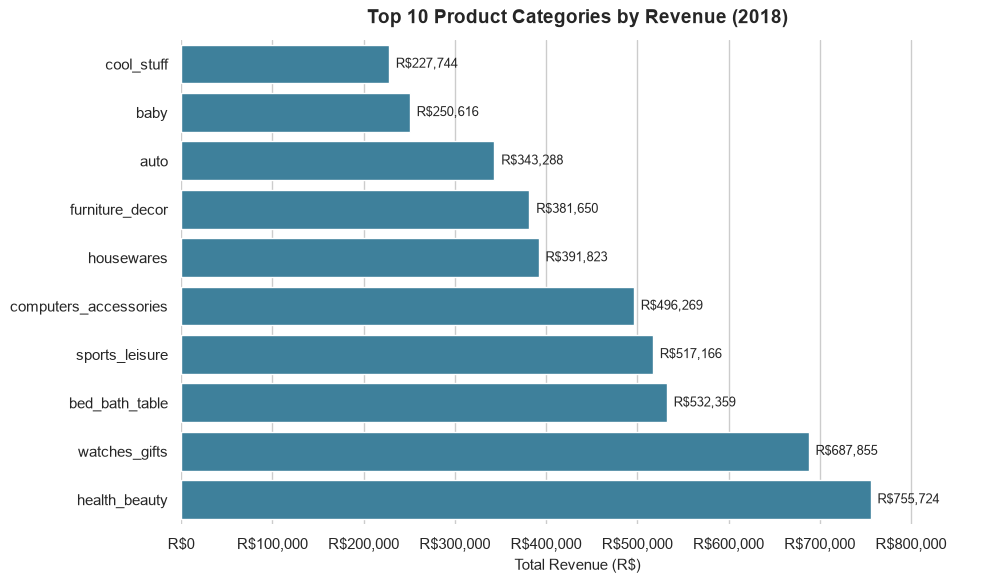

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_data = top10_categories_2018.sort_values('total_revenue', ascending=True)

sns.barplot(
    data=plot_data, y='product_category_name_english', x='total_revenue',
    color='#2E86AB', ax=ax,
)
ax.set_title('Top 10 Product Categories by Revenue (2018)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Total Revenue (R$)', fontsize=11)
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

for i, v in enumerate(plot_data['total_revenue']):
    ax.text(v + (plot_data['total_revenue'].max() * 0.01), i, f'R${v:,.0f}', va='center', fontsize=9)

ax.set_xlim(0, plot_data['total_revenue'].max() * 1.15)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## Chart 2 — Customer Distribution Across RFM Segments

Design choices: horizontal bars again for label readability, sorted by count
so segment size is instantly comparable, and a sequential color palette since
segments have a rough best-to-worst ordering (not arbitrary categories).

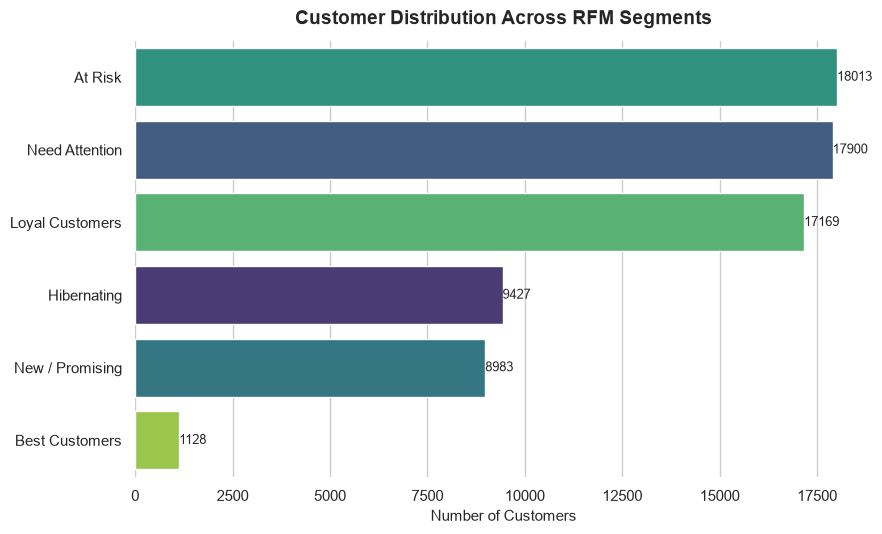

In [21]:
segment_order = rfm_df['segment'].value_counts().index.tolist()
counts = rfm_df['segment'].value_counts()

fig, ax = plt.subplots(figsize=(9, 5.5))
palette = sns.color_palette('viridis', n_colors=len(segment_order))
sns.countplot(
    data=rfm_df, y='segment', order=segment_order,
    hue='segment', palette=palette, legend=False, ax=ax,
)
ax.set_title('Customer Distribution Across RFM Segments', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Number of Customers', fontsize=11)
ax.set_ylabel('')

for i, seg in enumerate(segment_order):
    ax.text(counts[seg] + 0.3, i, str(counts[seg]), va='center', fontsize=9)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

---
# Conclusion

**Business Question 1 — Product Performance (2018):** the chart above ranks
the ten English-mapped categories that generated the most revenue across the
full 2018 calendar year, letting the business prioritize marketing spend and
inventory toward the categories actually driving revenue.

**Business Question 2 — Customer Segmentation (RFM, last 12 months):** the
segment distribution shows how the active customer base splits between
high-value loyal customers, at-risk customers who need a win-back push, and
hibernating customers who are unlikely to be worth aggressive re-engagement
spend. This gives a concrete, explainable basis for targeted CRM campaigns
rather than treating every customer the same.

Both results — the cleaned `dashboard/main_data.csv` and the RFM logic above —
feed directly into the companion Streamlit dashboard (`dashboard/dashboard.py`)
for interactive, filterable exploration.


In [4]:
# 1. Install semua library yang dibutuhkan
%pip install -r requirements.txt

  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached markupsafe-3.0.3-cp311-cp311-win_amd64.whl.metadata (2.8 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached notebook_shim-0.2.4-py3-none-any.whl.metadata (4.0 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached overrides-7.7.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached terminado-0.18.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached rfc3339_validator-0.1.4-py2.py3-none-any.whl.metadata (1.5 kB)
  Using cached rfc3986_validator-0.1.1-py2.py3-none-any.whl.metadata (1.7 kB)
  Using cached fqdn-1.5.1-py3-none-any.whl


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
